### Introduction

The Tour de France is one of the most demanding endurance events in proffesional sports, with over a century of historical data reflecting changes in performance, strategy and competitiveness.

This project explores how the competitive balance of the Tour de France has evolved over time. Specifically, it analyzes the time gap between first and second place in each edition of the race.

By converting historical race time differences into numerical values and applying a 5 year rolling average, this analysis aims to identify long-term trends in competitiveness and evaluate wether modern editions of the Tour are more tightly contested than earlier races.

Through this approach, the project highlights how performance analytics can provide insight into the structural evolution of endurance sports.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv('../data/tdf_finishers.csv')

In [43]:
df.columns

Index(['Year', 'Rank', 'Rider', 'Time', 'Team'], dtype='object')

In [44]:
df.head(5)

,Year,Rank,Rider,Time,Team
0,1903,1,Maurice Garin (FRA),"94h 33' 14""",La Française
1,1903,2,Lucien Pothier (FRA),"+ 2h 59' 21""",La Française
2,1903,3,Fernand Augereau (FRA),"+ 4h 29' 24""",La Française
3,1903,4,Rodolfo Muller[27] (ITA),"+ 4h 39' 30""",La Française
4,1903,5,Jean Fischer (FRA),"+ 4h 58' 44""",La Française


In [45]:
df['Rank'].describe()
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
df['Rank'].isna().sum()

df = df.dropna(subset=['Rank'])


In [46]:
df['Rank'] = df['Rank'].astype(int)


In [47]:
df['Rank'].min(), df['Rank'].max()

(1, 174)

In [48]:
# EDA for Time column
df['Time'].head(10)

0      94h 33' 14"
1     + 2h 59' 21"
2     + 4h 29' 24"
3     + 4h 39' 30"
4     + 4h 58' 44"
5     + 5h 52' 24"
6     + 8h 31' 08"
7    + 10h 24' 04"
8    + 10h 52' 14"
9    + 12h 44' 57"
Name: Time, dtype: object

In [49]:
df['Time'].tail(10)

9885    + 5h 13' 49"
9886    + 5h 15' 09"
9887    + 5h 15' 26"
9888    + 5h 20' 17"
9889    + 5h 23' 38"
9890    + 5h 30' 19"
9891    + 5h 31' 25"
9892    + 5h 31' 27"
9893    + 5h 36' 33"
9894    + 5h 40' 42"
Name: Time, dtype: object

In [50]:
import re

def time_gap_to_seconds(time_str):
    if pd.isna(time_str):
        return None
    
    time_str = str(time_str).strip()

    if not time_str.startswith('+'):
        return 0
    
    hours = 0
    minutes = 0
    seconds = 0

    h_match = re.search(r'(\d+)h', time_str)
    m_match = re.search(r"(\d+)'", time_str)
    s_match = re.search(r'(\d+)"', time_str)

    if h_match:
        hours = int(h_match.group(1))
    if m_match:
        minutes = int(m_match.group(1))
    if s_match:
        seconds = int(s_match.group(1))

    return hours * 3600 + minutes * 60 + seconds

df['gap_seconds'] = df['Time'].apply(time_gap_to_seconds)

df[['Rank', 'Time', 'gap_seconds']].head(5)

df['gap_minutes'] = df['gap_seconds'] / 60   

df[['Rank', 'Time', 'gap_minutes']].head(5)

,Rank,Time,gap_minutes
0,1,"94h 33' 14""",0.000000
1,2,"+ 2h 59' 21""",179.350000
2,3,"+ 4h 29' 24""",269.400000
3,4,"+ 4h 39' 30""",279.500000
4,5,"+ 4h 58' 44""",298.733333


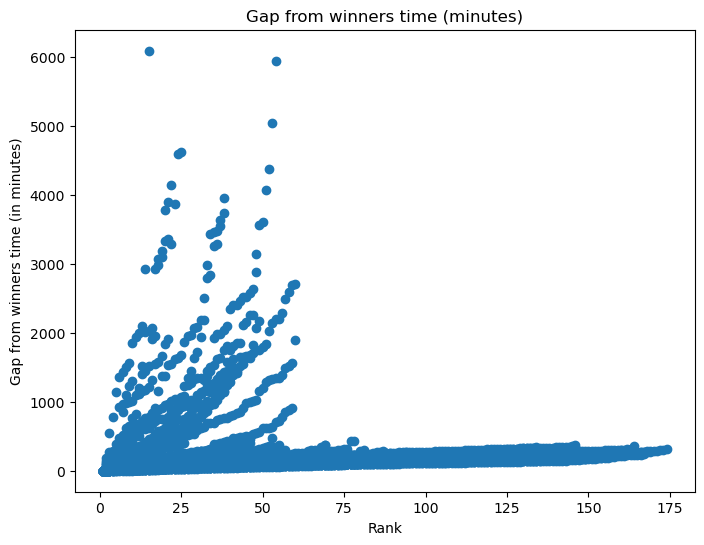

In [51]:
# create graph
plt.figure(figsize=(8,6))

plt.scatter(df['Rank'], df['gap_minutes'])

plt.xlabel('Rank')
plt.ylabel('Gap from winners time (in minutes)')
plt.title('Gap from winners time (minutes)')

plt.savefig('../images/gap_minutes', bbox_inches='tight')

plt.show()

In [52]:
# create dataframe of second place
second_place = df[df['Rank'] == 2].copy()
second_place.head()

,Year,Rank,Rider,Time,Team,gap_seconds,gap_minutes
1,1903,2,Lucien Pothier (FRA),"+ 2h 59' 21""",La Française,10761.0,179.350000
22,1904,2,Jean-Baptiste Dortignacq (FRA),"+ 2h 16' 14""",NaN,8174.0,136.233333
37,1905,2,Hippolyte Aucouturier (FRA),NaN,Peugeot-Wolber,NaN,NaN
61,1906,2,Georges Passerieu (FRA),NaN,Peugeot,NaN,NaN
75,1907,2,Gustave Garrigou (FRA),NaN,Peugeot-Wolber,NaN,NaN


In [53]:
# limpiar columnas de tiempo
second_place[['Time', 'gap_seconds', 'gap_minutes']].isna().sum()

Time           8
gap_seconds    8
gap_minutes    8
dtype: int64

In [54]:
second_place = second_place.dropna(subset=['gap_minutes'])

second_place[['Time', 'gap_seconds', 'gap_minutes']].isna().sum()

Time           0
gap_seconds    0
gap_minutes    0
dtype: int64

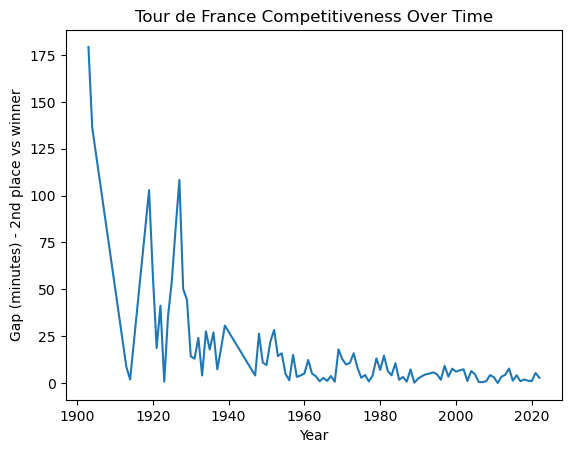

In [55]:
# graph for second place minute difference
plt.figure()

plt.plot(second_place['Year'], second_place['gap_minutes'])

plt.xlabel('Year')
plt.ylabel('Gap (minutes) - 2nd place vs winner')
plt.title('Tour de France Competitiveness Over Time')

plt.savefig('../images/tdf_competitiveness', bbox_inches='tight')

plt.show()


### Tour de France Competitiveness Over Time 

Early edition of the Tour de France show significantly larger time gaps between first and second place, suggesting greater performance disparities. Over time, the competition appears to have intensified, with modern races showing consistently smaller margins, indicating increaed parity among elite cyclist.

In [56]:
# create rolling average 
second_place = second_place.sort_values('Year')

second_place['rolling_5yr'] = (second_place['gap_minutes'].rolling(window=5).mean()
)

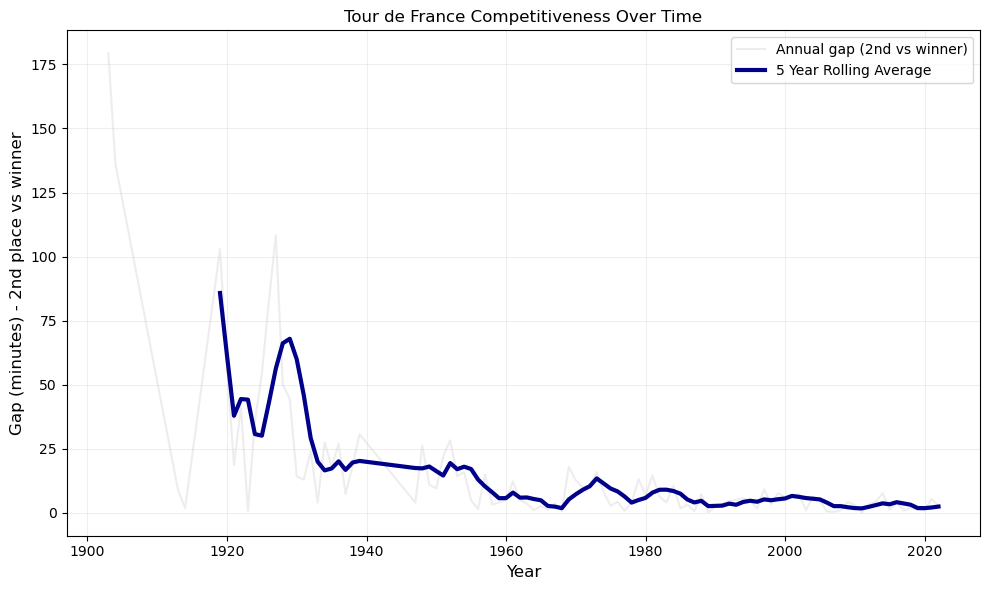

In [57]:
# graph for rolling average
plt.figure(figsize=(10,6))

# original line(light transparency)
plt.plot(
    second_place['Year'],
    second_place['gap_minutes'],
    color='lightgray',
    alpha=0.4,
    label='Annual gap (2nd vs winner)'
)

# rolling average (main line)
plt.plot(
    second_place['Year'],
    second_place['rolling_5yr'],
    color='darkblue',
    linewidth=3,
    label='5 Year Rolling Average'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Gap (minutes) - 2nd place vs winner', fontsize=12)
plt.title('Tour de France Competitiveness Over Time', fontsize=12)

plt.legend()
plt.grid(alpha=0.2)

plt.savefig('../images/tdf_competitiveness_rolling', bbox_inches='tight')

plt.tight_layout()
plt.show()

### Tour de France Competitiveness Over Time

The historical evolution of time gaps between first and second place suggests that the Tour de France has become progressively more competitive. Early editions were characterized by large performance disparities, while modern races show tighter margins and increased parity among elite cyclists.

This analysis explored how the time gao between first and second place in the Tour de France has evolved over more than a century.

The results show a clear long-term trend towards increased competitiveness:

- Early editions (1900-1930) were characterized by extremely large time gaps and high variability.
- Mid century races showed a gradual stabilization.
- In the modern era, time differences between the top two riders are consistently much smaller.

The 5 year rolling average highlights a structural shift in the sport, suggesting improved training methods, technology, team strategy and overall parity among elite cyclist.

Overall, the Tour de France has transitioned from an event with large performance disparities to one defined by marginal gains and tight competition at the top.